# Industrial Sensor EDA
## Exploratory Data Analysis: Gas Treatment Process

**Data:** 10 sensors from a gas treatment process (two process units)  
**Period:** Dec 23, 2014 → Jan 20, 2015 (28 days)  
**Resolution:** 1-hour intervals after preprocessing  

### EDA Structure
1. Load & basic info
2. Sensor overview — all time series
3. Controller analysis — PV vs SP deviations
4. Correlation matrix
5. Value distributions
6. Anomaly events — detailed zoom
7. Rolling volatility — anomaly precursors
8. Summary — anomaly labeling for ML models

## 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Load cleaned dataset (output of pipeline.py)
df = pd.read_csv('cleaned_dataset.csv',
                 index_col='timestamp', parse_dates=True)

print(f'Shape: {df.shape}')
print(f'Period: {df.index.min()} -> {df.index.max()}')
print(f'NaN: {df.isnull().sum().sum()}')
df.head(3)

Shape: (673, 52)
Period: 2014-12-23 08:00:00 -> 2015-01-20 08:00:00
NaN: 0


,TE301020,PDT31008,PDT31001,PDT31007,LT31013,FQ31050,LT301031,LIC31012_PV,LIC31012_OP,LIC31012_SP,...,PDT31008_roll3h_mean,PDT31008_roll3h_std,LT301031_roll3h_mean,LT301031_roll3h_std,FQ31050_roll3h_mean,FQ31050_roll3h_std,TE301020_roll3h_mean,TE301020_roll3h_std,hour_of_day,day_of_week
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-23 08:00:00,107.204,229.829,5.8195,54.5930,105.072,85.563,41.815,80.0,41.91,80.0,...,229.829,0.000000,41.815000,0.000000,85.563,0.00000,107.204,0.0,8,1
2014-12-23 09:00:00,107.204,229.829,5.8195,54.5930,105.081,85.563,41.815,80.0,41.91,80.0,...,229.829,0.000000,41.815000,0.000000,85.563,0.00000,107.204,0.0,9,1
2014-12-23 10:00:00,107.204,215.099,5.8195,52.6395,105.072,57.315,7.017,74.0,36.46,80.0,...,224.919,8.504369,30.215667,20.090635,76.147,16.30899,107.204,0.0,10,1


### Basic Statistics

In [3]:
# Basic statistics for core sensors
core_sensors = ['TE301020','PDT31008','PDT31001','PDT31007',
                'FQ31050','LT301031','LIC31012_PV','LIC31002_PV','FIC31011_PV']
units = {'TE301020':'degC','PDT31008':'mbar','PDT31001':'mbar','PDT31007':'mbar',
         'FQ31050':'m3/h','LT301031':'%','LIC31012_PV':'%','LIC31002_PV':'%','FIC31011_PV':'m3/h'}

stats = df[core_sensors].describe().round(2)
stats.loc['unit'] = [units[c] for c in core_sensors]
stats

,TE301020,PDT31008,PDT31001,PDT31007,FQ31050,LT301031,LIC31012_PV,LIC31002_PV,FIC31011_PV
count,673.0,673.0,673.0,673.0,673.0,673.0,673.0,673.0,673.0
mean,107.14,222.15,6.24,53.34,84.19,46.69,79.96,69.86,413.08
std,2.06,30.19,2.54,7.03,3.88,11.12,0.95,1.05,3.96
min,98.06,85.89,1.45,25.38,38.01,6.34,71.9,64.3,404.6
25%,105.88,210.13,3.9,50.62,82.97,41.58,79.7,69.7,410.3
50%,106.89,222.45,6.47,54.04,84.19,46.49,80.0,70.0,412.4
75%,108.22,235.4,8.4,56.22,85.6,53.42,80.2,70.25,415.7
max,118.28,378.46,20.4,74.66,105.85,102.12,86.5,74.85,427.7
unit,degC,mbar,mbar,mbar,m3/h,%,%,%,m3/h


## Known Anomaly Periods
Identified from visual inspection of raw trend graphs.

In [4]:
ANOMALY_PERIODS = [
    ('2014-12-25 22:00', '2014-12-26 02:00', '#FF6B6B', 'FIC31011 spike'),
    ('2014-12-28 00:00', '2014-12-30 23:00', '#FFA07A', 'PDT31008 high pressure'),
    ('2015-01-02 00:00', '2015-01-03 23:00', '#FF4444', 'MAJOR: LIC31002 deviation'),
    ('2015-01-10 00:00', '2015-01-11 23:00', '#CC0000', 'PDT31008 max 378 mbar'),
    ('2015-01-12 00:00', '2015-01-13 23:00', '#FF4444', 'MAJOR: LT301031 swings'),
    ('2015-01-18 00:00', '2015-01-19 00:00', '#FFA07A', 'LIC31002 deviation'),
]

def add_anomaly_bands(ax):
    for start, end, color, label in ANOMALY_PERIODS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.15, color=color, zorder=0)

print('Anomaly periods defined:', len(ANOMALY_PERIODS))

Anomaly periods defined: 6


## 2. All Sensors — Time Series Overview

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(18, 20), sharex=True)
fig.suptitle('Gas Treatment Process — Sensor Overview\n(28-day operational dataset)',
             fontsize=14, fontweight='bold', y=0.98)

plots = [
    ('TE301020',    'Temperature (°C)',    '#E74C3C', 'Unit B — Amine Temperature'),
    ('PDT31008',    'Pressure diff (mbar)','#3498DB', 'D304 — Pressure Differential'),
    ('LT301031',    'Level (%)',           '#2ECC71', 'D304 — Liquid Level (volatile)'),
    ('FQ31050',     'Steam flow (m³/h)',   '#9B59B6', 'D304 — Steam Flow'),
    ('FIC31011_PV', 'Reflux flow (m³/h)', '#F39C12', 'D304 — Reflux Flow Controller'),
]

for ax, (col, ylabel, color, title) in zip(axes, plots):
    ax.plot(df.index, df[col], color=color, linewidth=0.8, alpha=0.9)
    max_col = f'{col}_max'
    if max_col in df.columns:
        ax.fill_between(df.index, df[col], df[max_col], alpha=0.2, color=color)
    add_anomaly_bands(ax)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, loc='left', pad=3)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 3. Controller Analysis — LIC31002
**LIC31002** is the most informative signal for anomaly detection:
- SP changed multiple times (65% → 70% → 92% → 70%)
- Major deviation of **+20.9%** occurred on Jan 2 — visible process upset


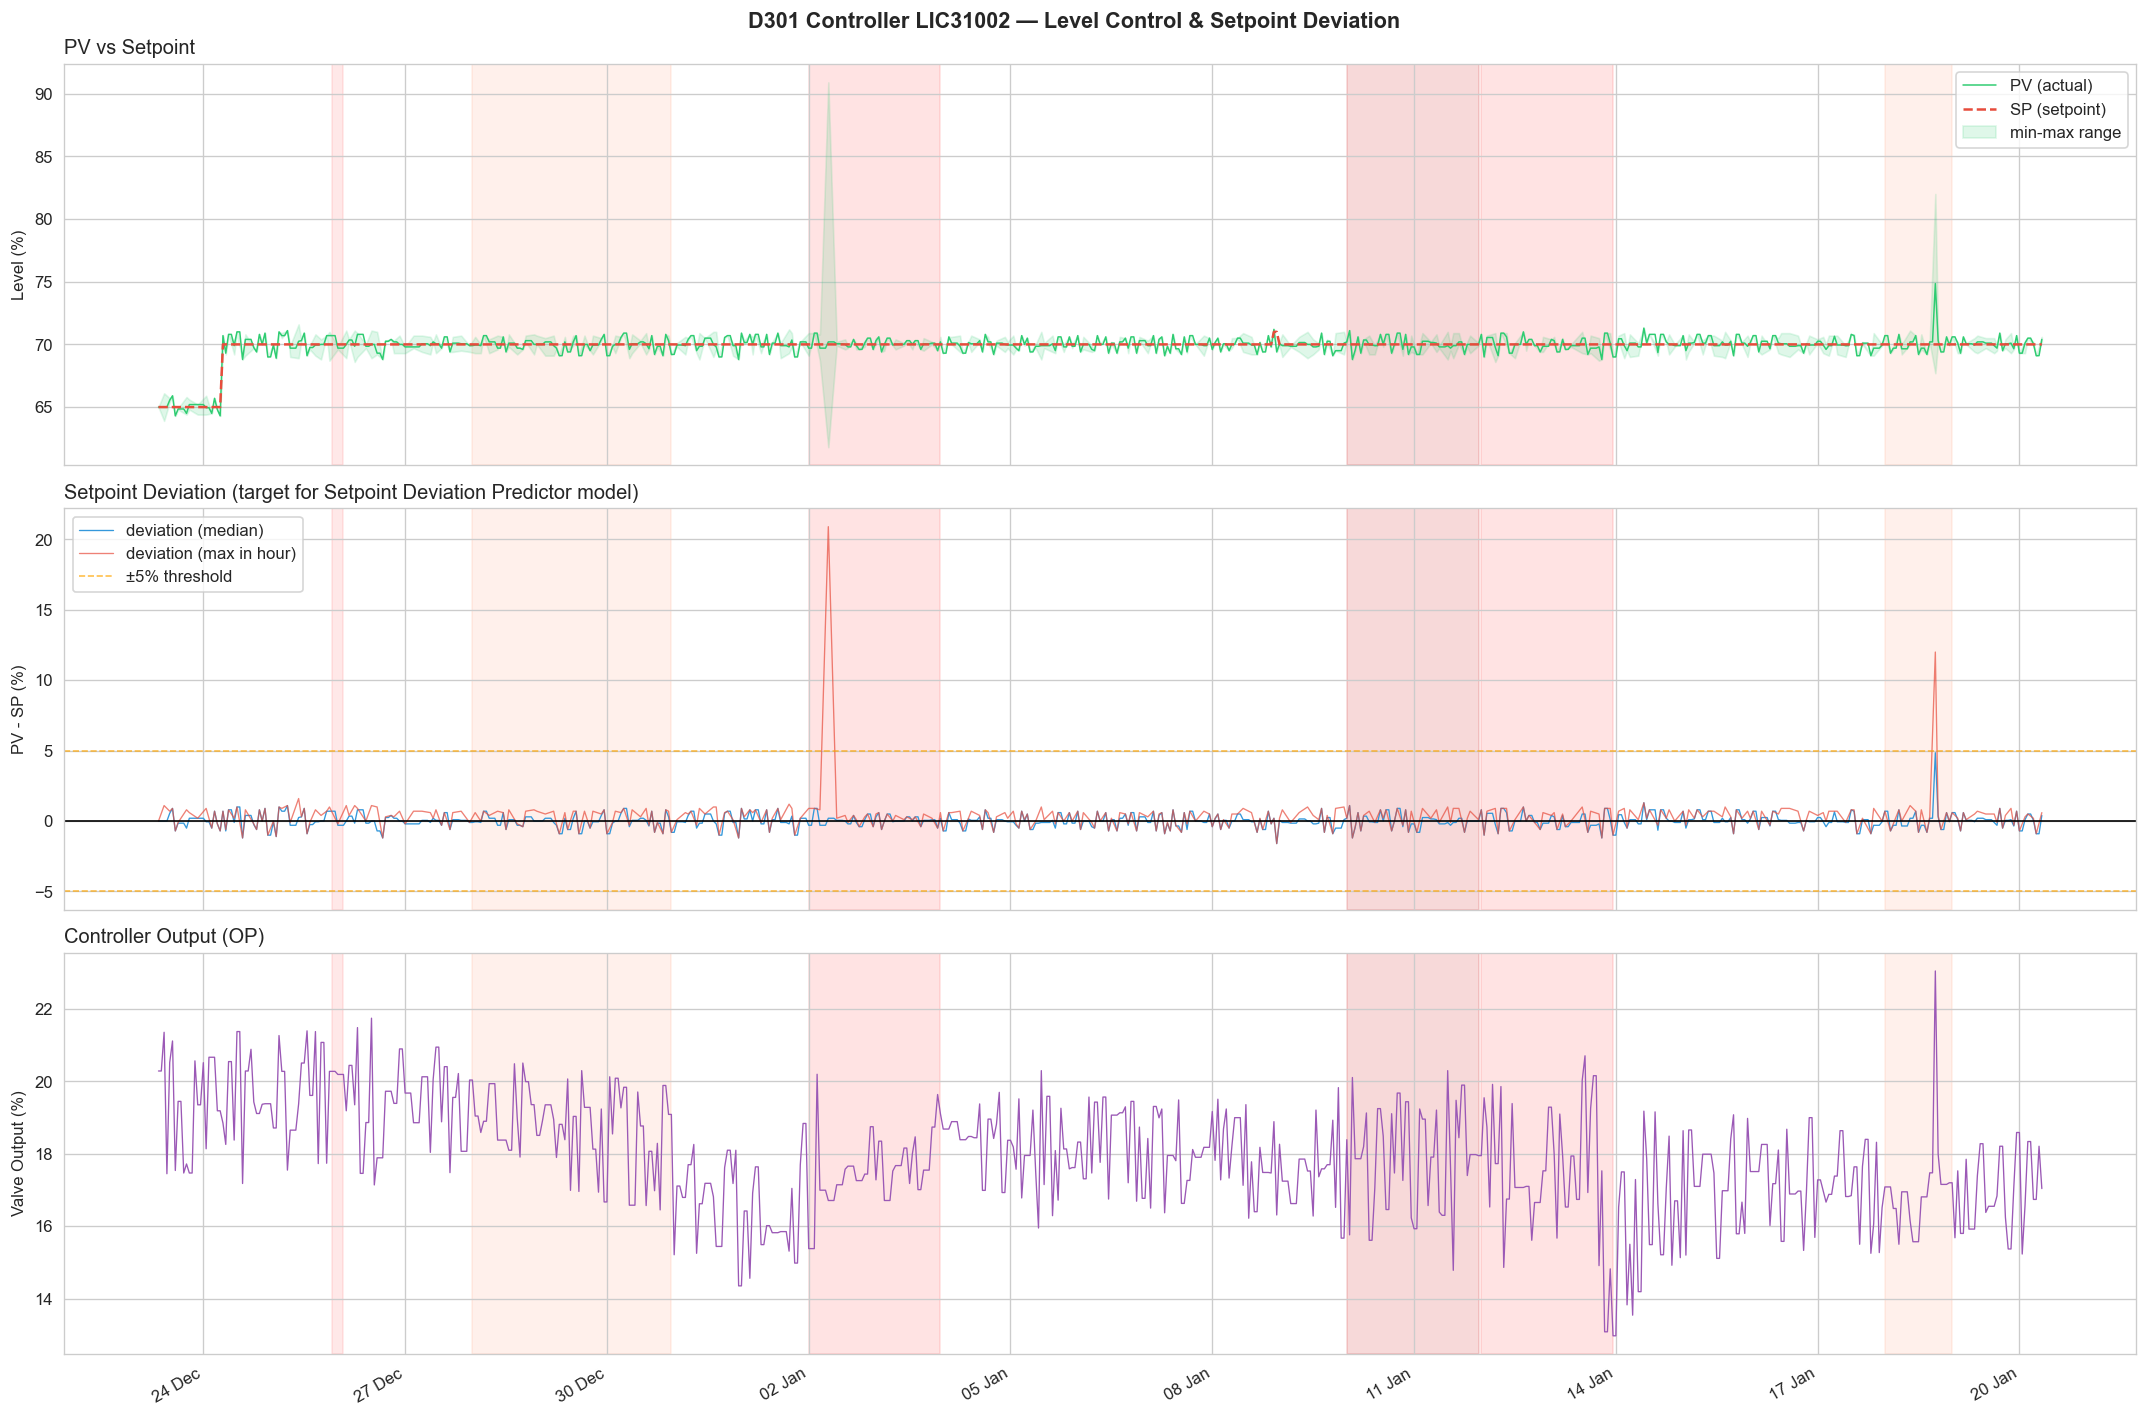

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle('D301 Controller LIC31002 — Level Control & Setpoint Deviation',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(df.index, df['LIC31002_PV'], color='#2ECC71', linewidth=0.9, label='PV (actual)')
ax.plot(df.index, df['LIC31002_SP'], color='#E74C3C', linewidth=1.5,
        linestyle='--', label='SP (setpoint)')
ax.fill_between(df.index, df['LIC31002_PV_min'], df['LIC31002_PV_max'],
                alpha=0.15, color='#2ECC71', label='min-max range')
add_anomaly_bands(ax)
ax.set_ylabel('Level (%)')
ax.set_title('PV vs Setpoint', loc='left')
ax.legend()

ax = axes[1]
ax.plot(df.index, df['LIC31002_deviation'], color='#3498DB', linewidth=0.8, label='deviation (median)')
ax.plot(df.index, df['LIC31002_deviation_max'], color='#E74C3C', linewidth=0.8,
        alpha=0.7, label='deviation (max in hour)')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(5, color='orange', linewidth=1, linestyle='--', alpha=0.7, label='±5% threshold')
ax.axhline(-5, color='orange', linewidth=1, linestyle='--', alpha=0.7)
add_anomaly_bands(ax)
ax.set_ylabel('PV - SP (%)')
ax.set_title('Setpoint Deviation (target for Setpoint Deviation Predictor model)', loc='left')
ax.legend()

ax = axes[2]
ax.plot(df.index, df['LIC31002_OP'], color='#9B59B6', linewidth=0.8)
add_anomaly_bands(ax)
ax.set_ylabel('Valve Output (%)')
ax.set_title('Controller Output (OP)', loc='left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Correlation Matrix

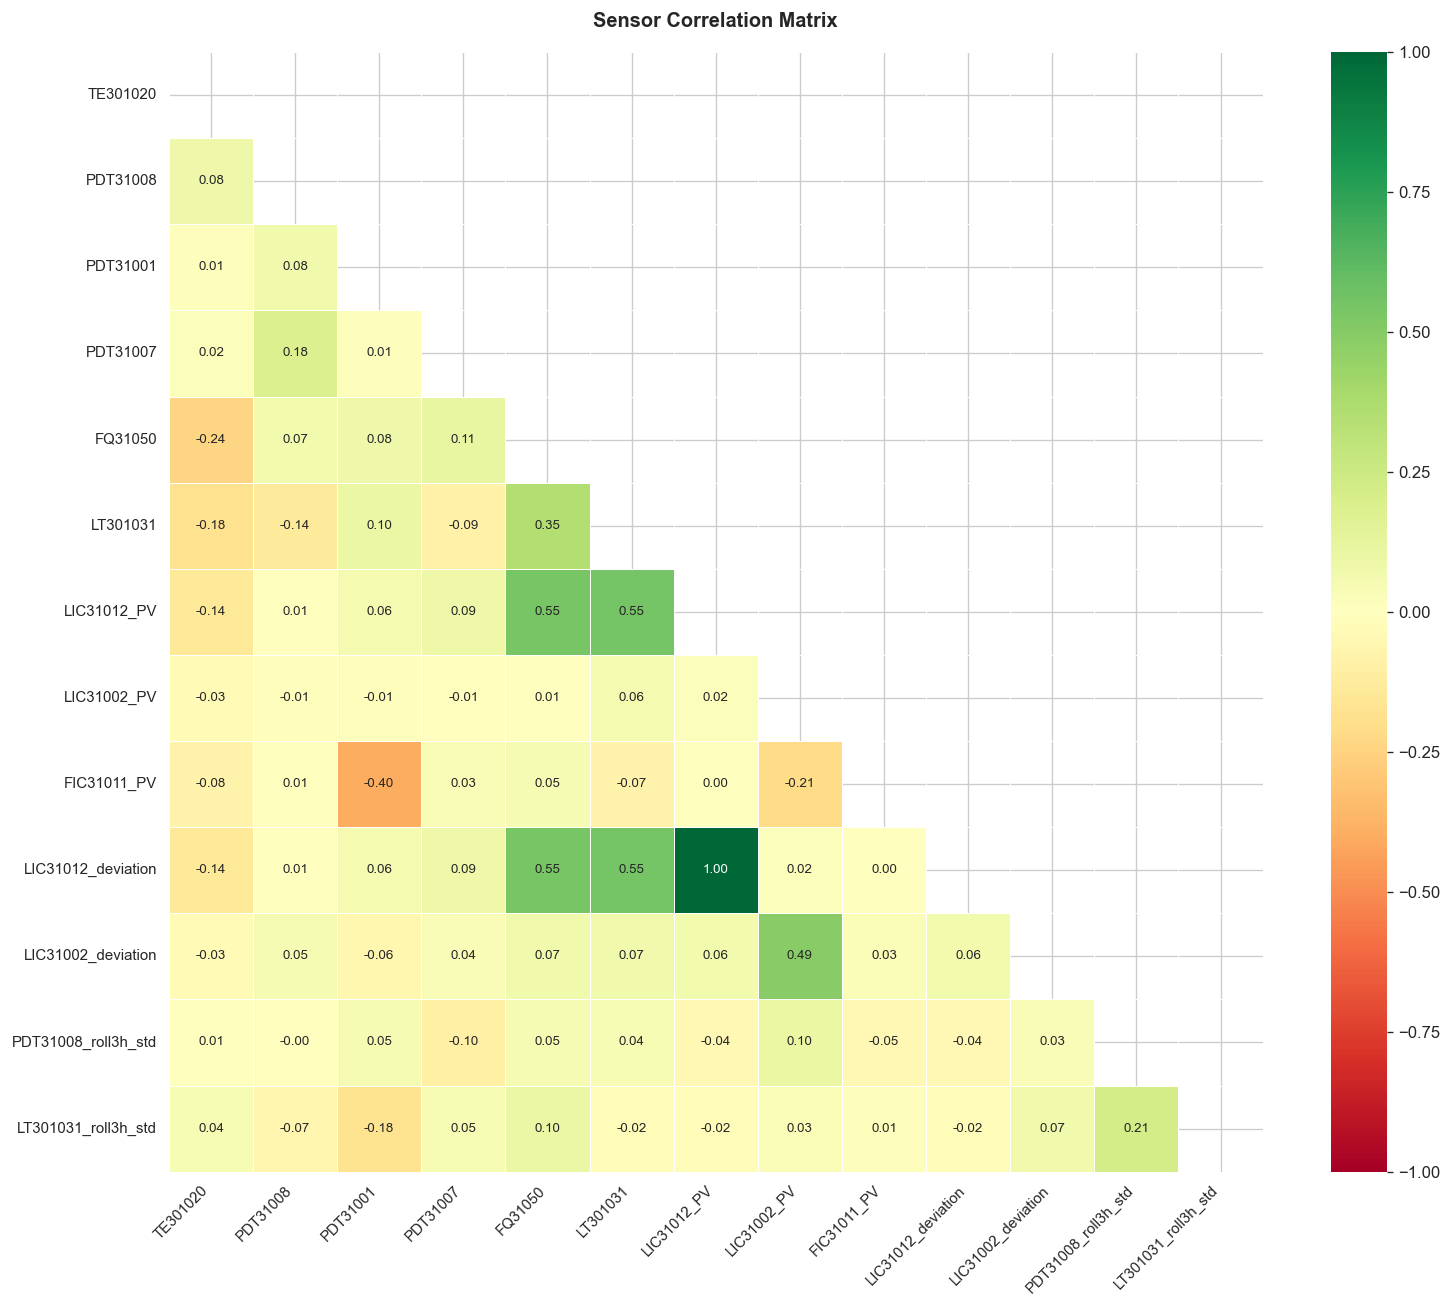

Top 10 strongest correlations:
LIC31012_deviation  LT301031              0.546885
LT301031            LIC31012_deviation    0.546885
LIC31012_PV         LT301031              0.546885
LT301031            LIC31012_PV           0.546885
LIC31012_PV         FQ31050               0.545548
FQ31050             LIC31012_PV           0.545548
                    LIC31012_deviation    0.545548
LIC31012_deviation  FQ31050               0.545548
LIC31002_PV         LIC31002_deviation    0.491708
LIC31002_deviation  LIC31002_PV           0.491708


In [7]:
core_cols = ['TE301020','PDT31008','PDT31001','PDT31007',
             'FQ31050','LT301031','LIC31012_PV','LIC31002_PV',
             'FIC31011_PV','LIC31012_deviation','LIC31002_deviation',
             'PDT31008_roll3h_std','LT301031_roll3h_std']

corr = df[core_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Sensor Correlation Matrix', fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Top correlations
corr_unstacked = corr.abs().unstack()
corr_sorted = corr_unstacked[corr_unstacked < 1.0].sort_values(ascending=False)
print('Top 10 strongest correlations:')
print(corr_sorted.head(10).to_string())

## 5. Value Distributions

In [ ]:
sensor_cols = ['TE301020','PDT31008','PDT31001','PDT31007',
               'FQ31050','LT301031','LIC31012_PV','LIC31002_PV','FIC31011_PV']
units_map = ['°C','mbar','mbar','mbar','m³/h','%','%','%','m³/h']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Sensor Value Distributions — Gas Treatment Process', fontsize=13, fontweight='bold')

for ax, col, unit in zip(axes.flat, sensor_cols, units_map):
    data = df[col].dropna()
    ax.hist(data, bins=40, color='#3498DB', alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='#E74C3C', linewidth=2, linestyle='--',
               label=f'mean={data.mean():.1f}')
    ax.axvline(data.median(), color='#2ECC71', linewidth=2, linestyle=':',
               label=f'median={data.median():.1f}')
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    ax.axvline(Q1 - 1.5*IQR, color='orange', linewidth=1, linestyle='--', alpha=0.7, label='IQR bounds')
    ax.axvline(Q3 + 1.5*IQR, color='orange', linewidth=1, linestyle='--', alpha=0.7)
    ax.set_title(f'{col} ({unit})', fontsize=10, fontweight='bold')
    ax.set_xlabel(unit, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Anomaly Events — Detailed Zoom

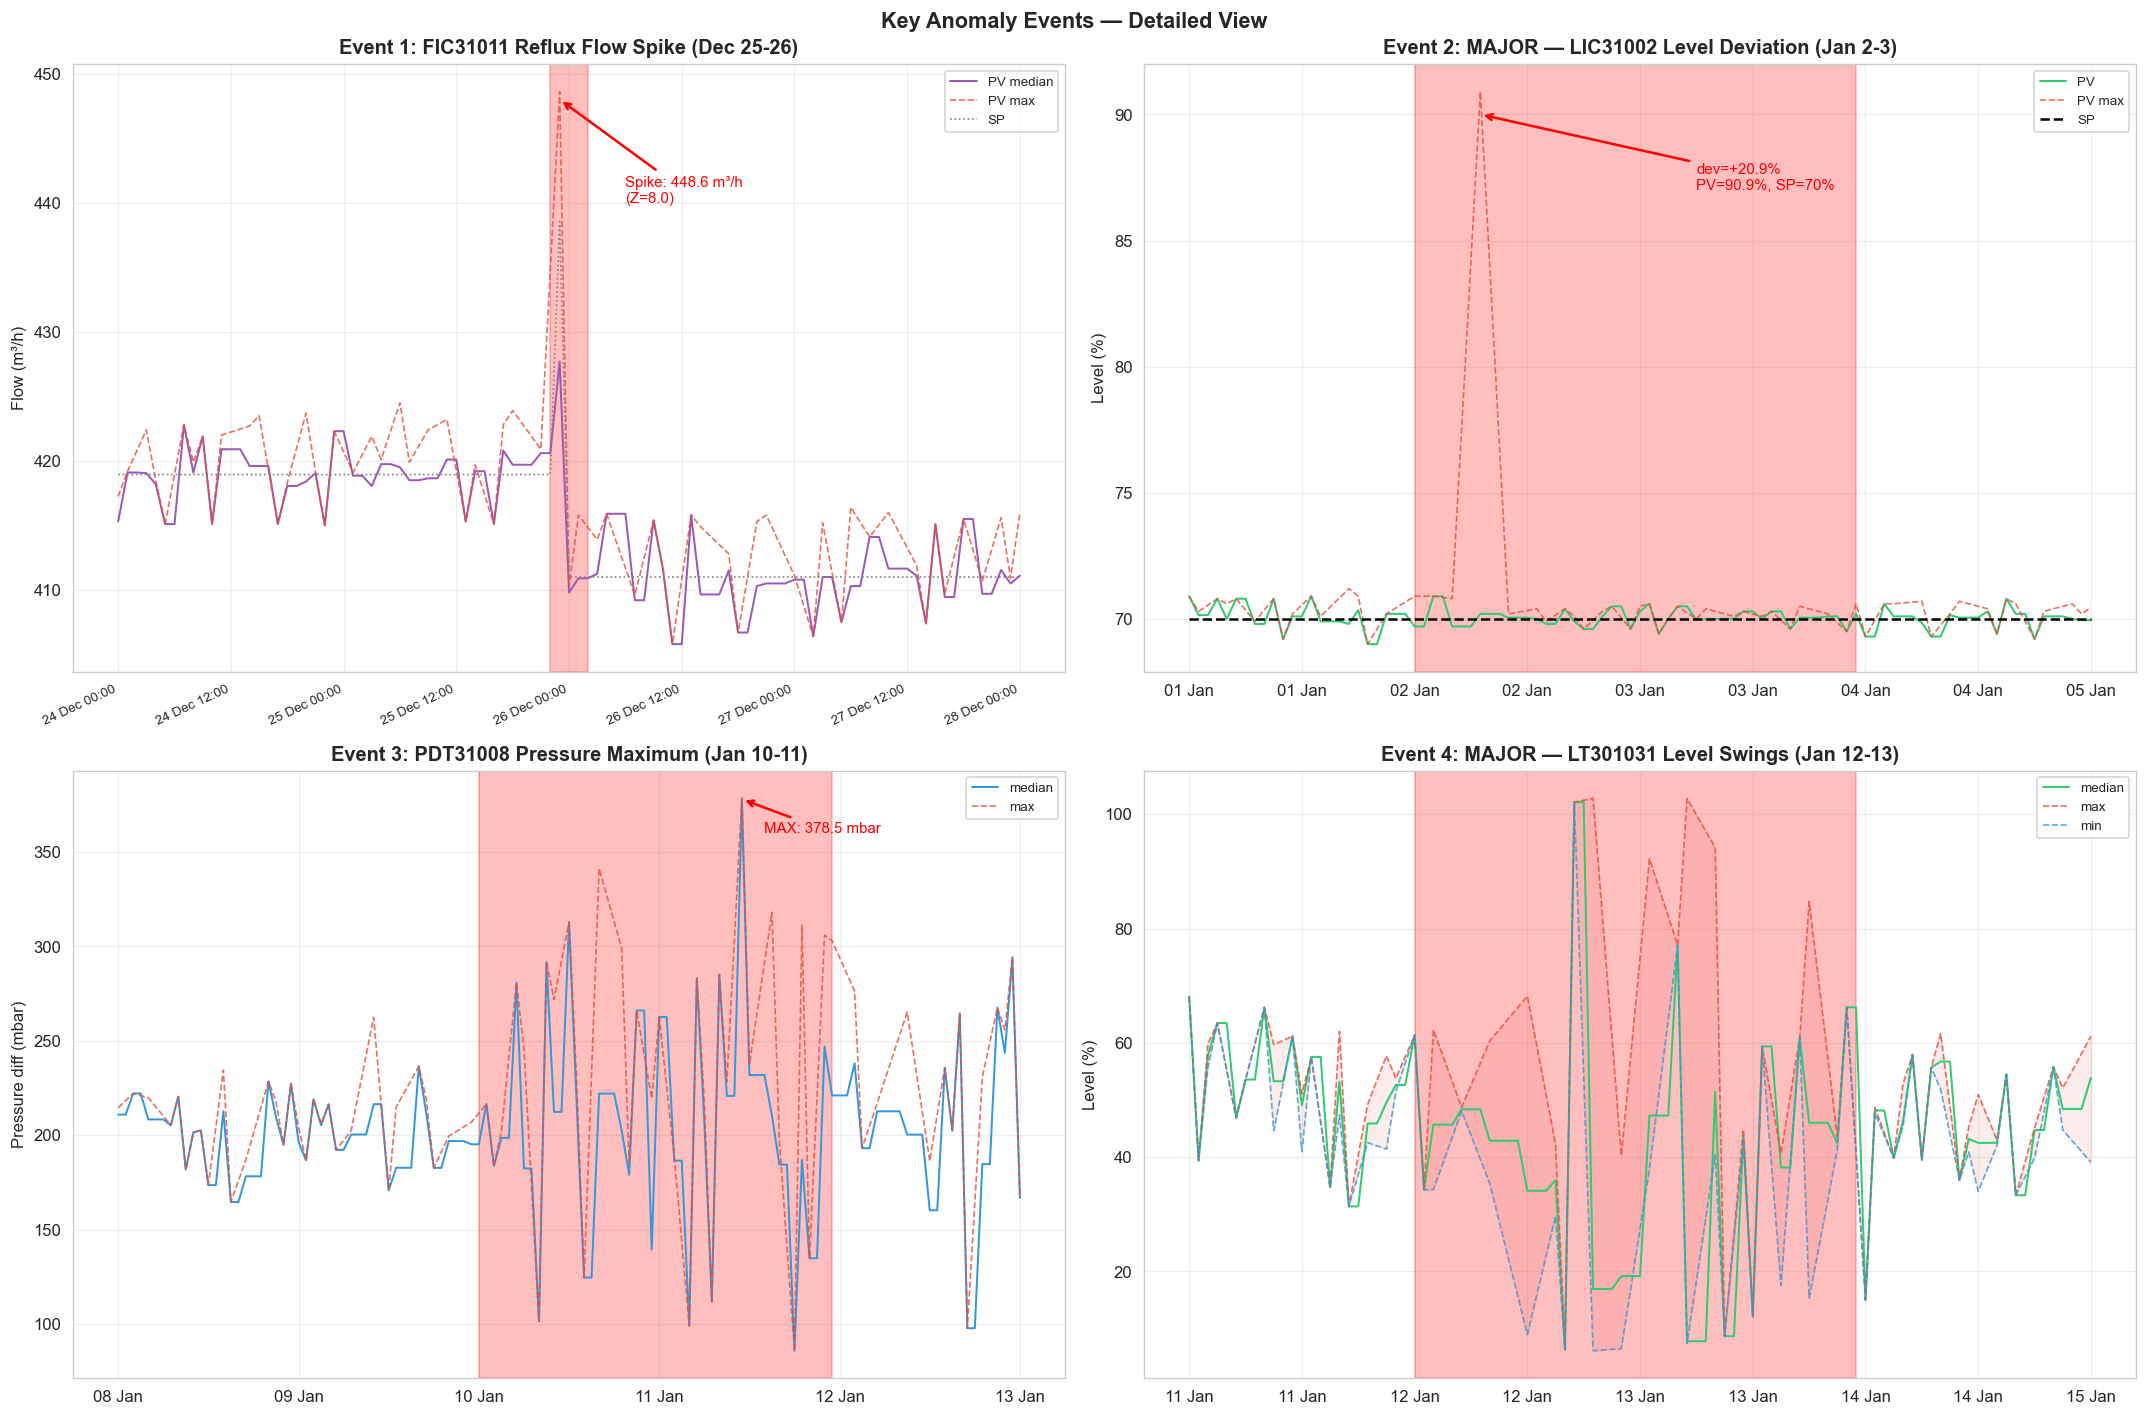

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Key Anomaly Events — Detailed View', fontsize=13, fontweight='bold')

# Event 1: FIC31011 spike Dec 25-26
ax = axes[0, 0]
mask = (df.index >= '2014-12-24') & (df.index <= '2014-12-28')
ax.plot(df.index[mask], df.loc[mask,'FIC31011_PV'], color='#9B59B6', linewidth=1.2, label='PV median')
ax.plot(df.index[mask], df.loc[mask,'FIC31011_PV_max'], color='#E74C3C',
        linewidth=1, linestyle='--', alpha=0.8, label='PV max')
ax.plot(df.index[mask], df.loc[mask,'FIC31011_SP'], color='gray', linewidth=1, linestyle=':', label='SP')
ax.axvspan(pd.Timestamp('2014-12-25 22:00'), pd.Timestamp('2014-12-26 02:00'), alpha=0.25, color='red')
ax.annotate('Spike: 448.6 m³/h\n(Z=8.0)',
            xy=(pd.Timestamp('2014-12-25 23:00'), 448),
            xytext=(pd.Timestamp('2014-12-26 06:00'), 440), fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.set_title('Event 1: FIC31011 Reflux Flow Spike (Dec 25-26)', fontweight='bold')
ax.set_ylabel('Flow (m³/h)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=8)

# Event 2: LIC31002 MAJOR Jan 2-3
ax = axes[0, 1]
mask = (df.index >= '2015-01-01') & (df.index <= '2015-01-05')
ax.plot(df.index[mask], df.loc[mask,'LIC31002_PV'], color='#2ECC71', linewidth=1.2, label='PV')
ax.plot(df.index[mask], df.loc[mask,'LIC31002_PV_max'], color='#E74C3C',
        linewidth=1, linestyle='--', alpha=0.8, label='PV max')
ax.plot(df.index[mask], df.loc[mask,'LIC31002_SP'], color='black',
        linewidth=1.5, linestyle='--', label='SP')
ax.axvspan(pd.Timestamp('2015-01-02 00:00'), pd.Timestamp('2015-01-03 23:00'), alpha=0.25, color='red')
ax.annotate('dev=+20.9%\nPV=90.9%, SP=70%',
            xy=(pd.Timestamp('2015-01-02 07:00'), 90),
            xytext=(pd.Timestamp('2015-01-03 06:00'), 87), fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.set_title('Event 2: MAJOR — LIC31002 Level Deviation (Jan 2-3)', fontweight='bold')
ax.set_ylabel('Level (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Event 3: PDT31008 max Jan 10-11
ax = axes[1, 0]
mask = (df.index >= '2015-01-08') & (df.index <= '2015-01-13')
ax.plot(df.index[mask], df.loc[mask,'PDT31008'], color='#3498DB', linewidth=1.2, label='median')
ax.plot(df.index[mask], df.loc[mask,'PDT31008_max'], color='#E74C3C',
        linewidth=1, linestyle='--', alpha=0.8, label='max')
ax.axvspan(pd.Timestamp('2015-01-10 00:00'), pd.Timestamp('2015-01-11 23:00'), alpha=0.25, color='red')
ax.annotate('MAX: 378.5 mbar',
            xy=(pd.Timestamp('2015-01-11 11:00'), 378),
            xytext=(pd.Timestamp('2015-01-11 14:00'), 360), fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.set_title('Event 3: PDT31008 Pressure Maximum (Jan 10-11)', fontweight='bold')
ax.set_ylabel('Pressure diff (mbar)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Event 4: LT301031 swings Jan 12-13
ax = axes[1, 1]
mask = (df.index >= '2015-01-11') & (df.index <= '2015-01-15')
ax.plot(df.index[mask], df.loc[mask,'LT301031'], color='#2ECC71', linewidth=1.2, label='median')
ax.plot(df.index[mask], df.loc[mask,'LT301031_max'], color='#E74C3C',
        linewidth=1, linestyle='--', alpha=0.8, label='max')
ax.plot(df.index[mask], df.loc[mask,'LT301031_min'], color='#3498DB',
        linewidth=1, linestyle='--', alpha=0.8, label='min')
ax.fill_between(df.index[mask], df.loc[mask,'LT301031_min'], df.loc[mask,'LT301031_max'],
                alpha=0.1, color='#E74C3C')
ax.axvspan(pd.Timestamp('2015-01-12 00:00'), pd.Timestamp('2015-01-13 23:00'), alpha=0.25, color='red')
ax.set_title('Event 4: MAJOR — LT301031 Level Swings (Jan 12-13)', fontweight='bold')
ax.set_ylabel('Level (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.show()

## 7. Rolling Volatility — Anomaly Precursors

High std = high instability = potential anomaly.
This is a key feature for Isolation Forest and XGBoost.


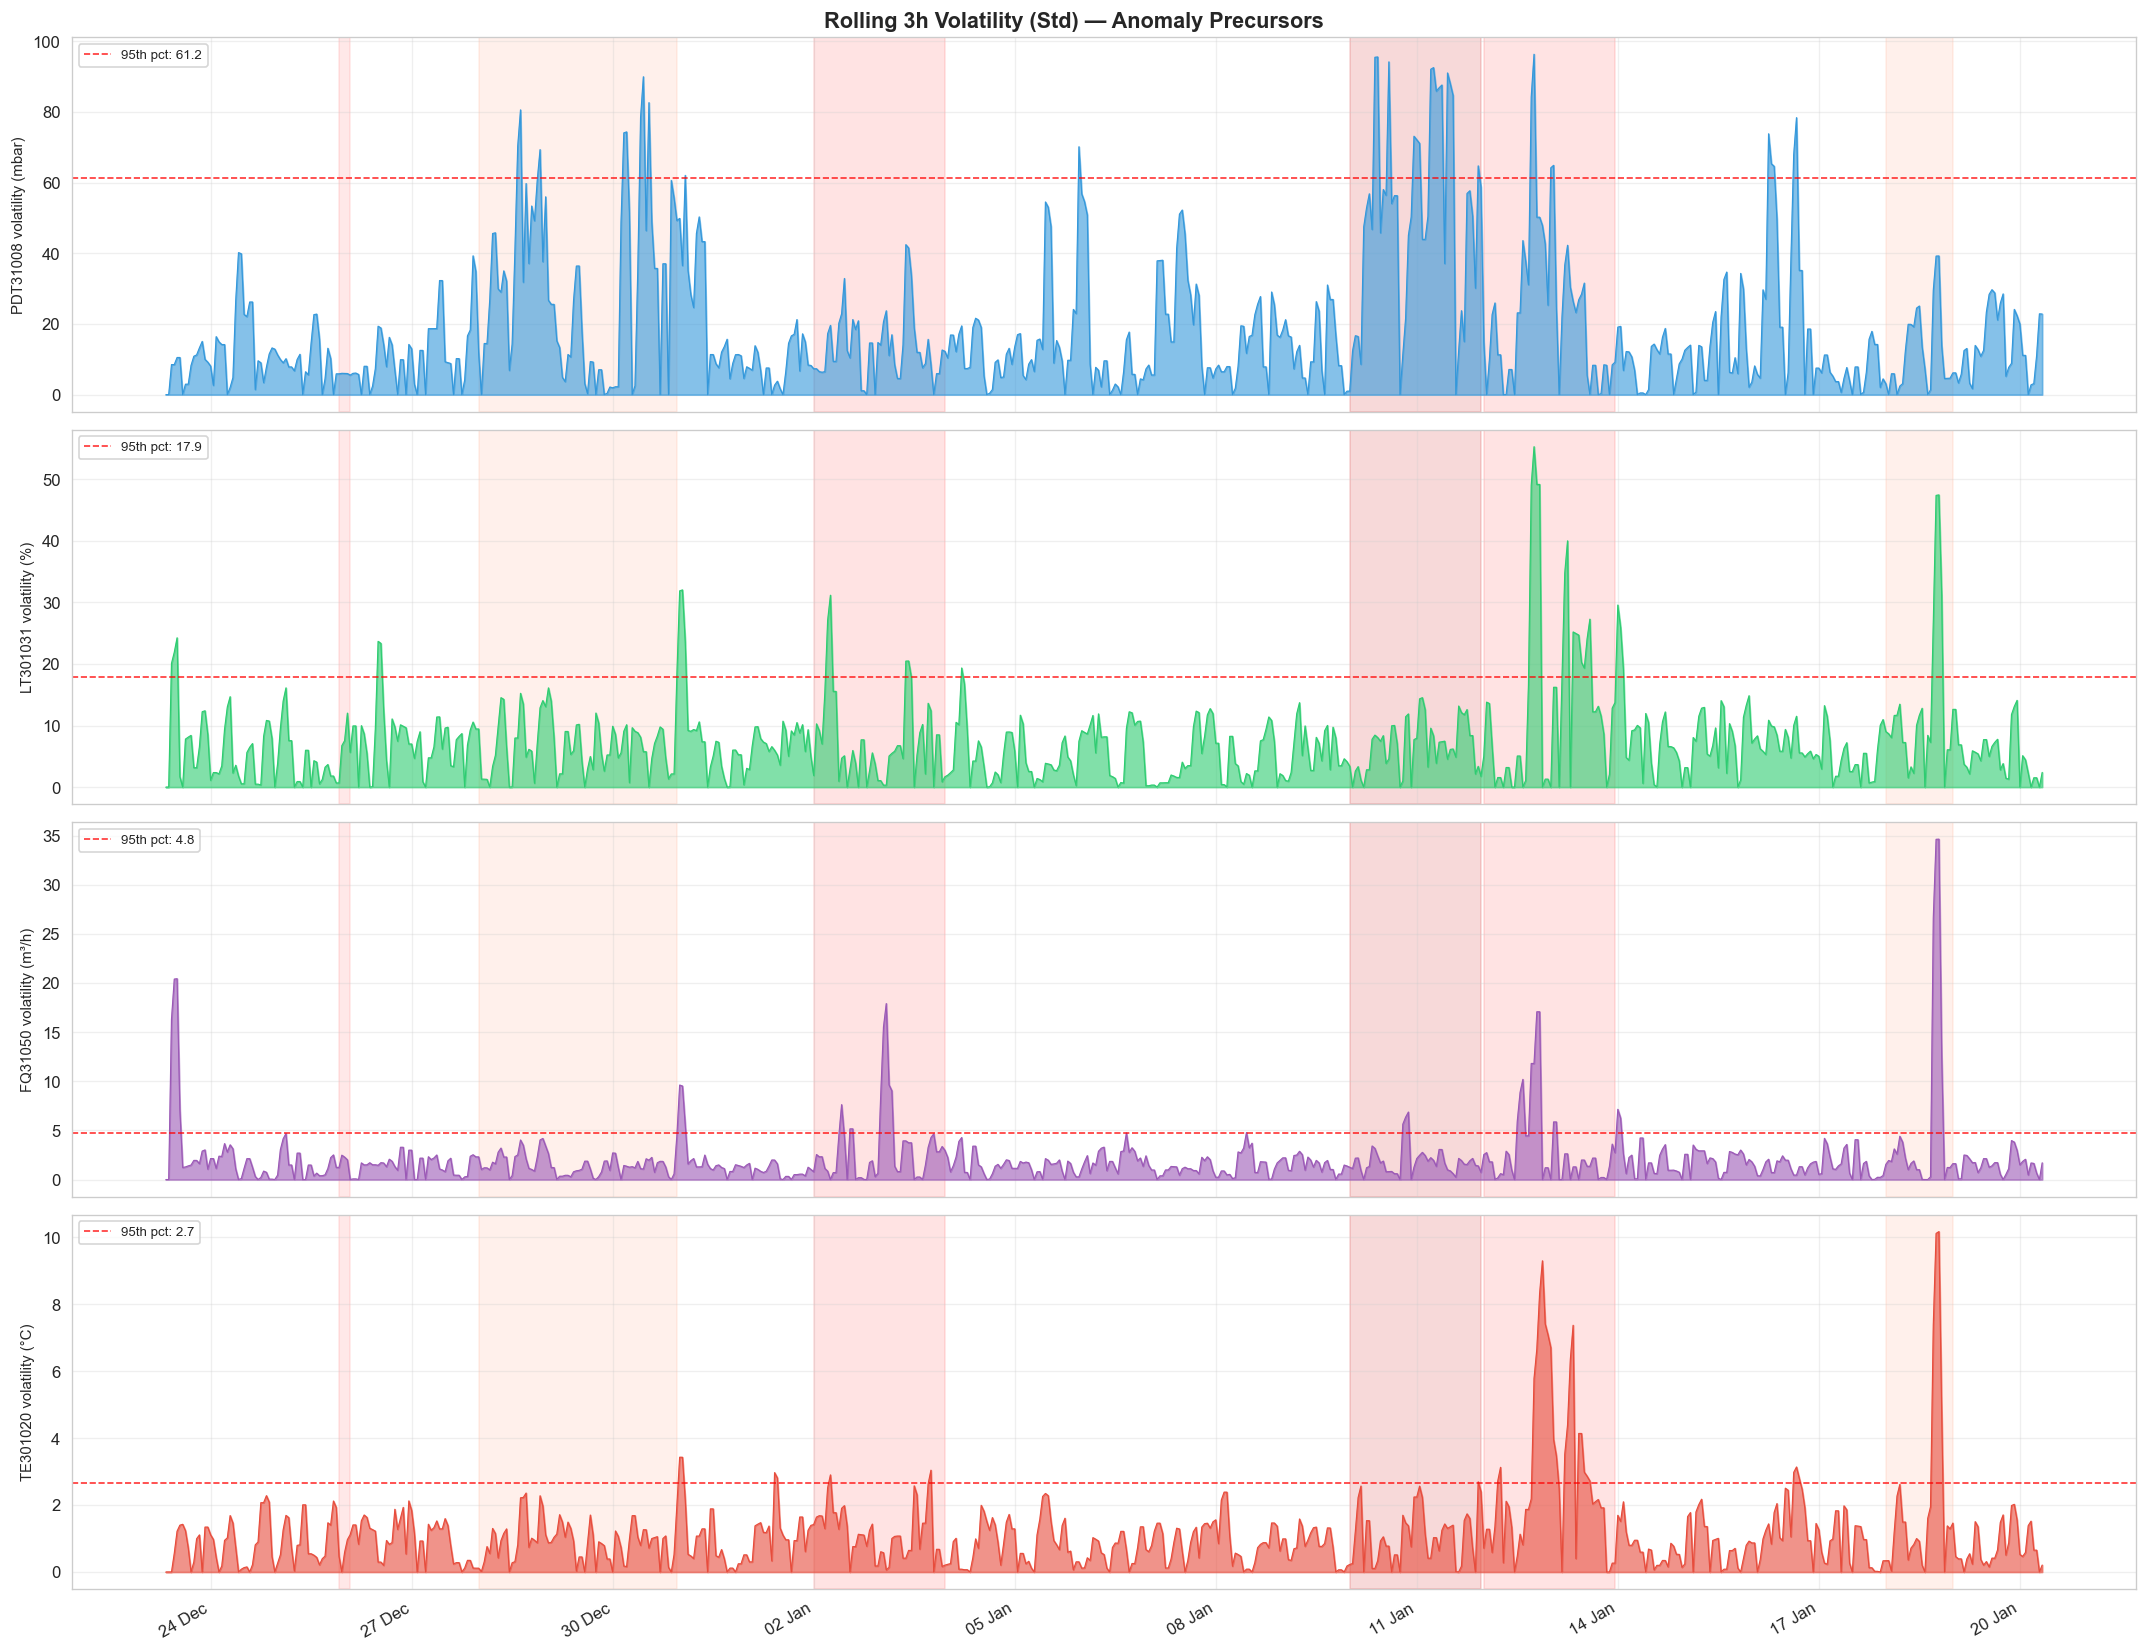

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle('Rolling 3h Volatility (Std) — Anomaly Precursors', fontsize=13, fontweight='bold')

vol_plots = [
    ('PDT31008_roll3h_std', 'PDT31008 volatility (mbar)', '#3498DB'),
    ('LT301031_roll3h_std', 'LT301031 volatility (%)',    '#2ECC71'),
    ('FQ31050_roll3h_std',  'FQ31050 volatility (m³/h)',  '#9B59B6'),
    ('TE301020_roll3h_std', 'TE301020 volatility (°C)',   '#E74C3C'),
]

for ax, (col, ylabel, color) in zip(axes, vol_plots):
    ax.fill_between(df.index, 0, df[col], alpha=0.6, color=color)
    ax.plot(df.index, df[col], color=color, linewidth=0.7)
    add_anomaly_bands(ax)
    threshold = df[col].quantile(0.95)
    ax.axhline(threshold, color='red', linewidth=1, linestyle='--',
               alpha=0.8, label=f'95th pct: {threshold:.1f}')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Rule-Based Anomaly Labeling

Since this dataset has **no ground truth labels**, we create them using:
1. Known anomaly periods (from trend graphs)
2. Statistical rules (IQR, std thresholds)

This labeled dataset will train the **XGBoost Regime Classifier**.

In [11]:
# Create anomaly label based on known periods
df['anomaly_label'] = 0  # 0 = normal

# Mark known anomaly periods
for start, end, _, label in ANOMALY_PERIODS:
    mask = (df.index >= start) & (df.index <= end)
    df.loc[mask, 'anomaly_label'] = 1

# Also flag using statistical rules
# PDT31008 > 300 mbar = anomaly
df.loc[df['PDT31008_max'] > 300, 'anomaly_label'] = 1
# LIC31002_deviation_max > 10% = anomaly
df.loc[df['LIC31002_deviation_max'].abs() > 10, 'anomaly_label'] = 1
# LT301031 roll std > 20 = anomaly (extreme swings)
df.loc[df['LT301031_roll3h_std'] > 20, 'anomaly_label'] = 1

# 3-class regime: 0=normal, 1=transition, 2=alarm
df['regime'] = 0
# Transition: rolling std elevated but not extreme
pdt_95 = df['PDT31008_roll3h_std'].quantile(0.90)
lt_95  = df['LT301031_roll3h_std'].quantile(0.90)
transition_mask = ((df['PDT31008_roll3h_std'] > pdt_95) |
                   (df['LT301031_roll3h_std'] > lt_95)) & (df['anomaly_label'] == 0)
df.loc[transition_mask, 'regime'] = 1
# Alarm: known anomaly periods
df.loc[df['anomaly_label'] == 1, 'regime'] = 2

print('Anomaly distribution:')
print(df['anomaly_label'].value_counts())
print()
print('Regime distribution:')
regime_map = {0: 'Normal', 1: 'Transition', 2: 'Alarm'}
for k, v in df['regime'].value_counts().sort_index().items():
    print(f'  {regime_map[k]:12s} ({k}): {v} hours ({v/len(df)*100:.1f}%)')

Anomaly distribution:
anomaly_label
0    410
1    263
Name: count, dtype: int64

Regime distribution:
  Normal       (0): 386 hours (57.4%)
  Transition   (1): 24 hours (3.6%)
  Alarm        (2): 263 hours (39.1%)


### Save Labeled Dataset

In [13]:
# Save labeled dataset for ML models
df.to_csv('labeled_dataset.csv')
print('Saved: labeled_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns[-5:])}')

Saved: labeled_dataset.csv
Shape: (673, 54)
Columns: ['TE301020_roll3h_std', 'hour_of_day', 'day_of_week', 'anomaly_label', 'regime']


## EDA Summary

### Key findings:

| Sensor | Key observation |
|--------|-----------------|
| TE301020 | Stable ~107°C, minor rise Jan 2-3 (+5°C) |
| PDT31008 | Most volatile, max 378.5 mbar on Jan 11 |
| PDT31001 | Quiet D301 sensor, single spike Jan 10 |
| LT31013  | **Saturated at ~105%** — sensor hardware issue |
| LT301031 | High variability (std=13.3%) — swings 6-102% |
| FQ31050  | Steam flow, drops correlated with level swings |
| LIC31002 | Most informative: SP changes + +20.9% deviation |
| FIC31011 | Spike to 448.6 m³/h on Dec 25 (Z=8.0) |

### For ML models:
- **Isolation Forest** → features: all 52 columns from cleaned_dataset.csv
- **XGBoost Classifier** → target: `regime` (0=Normal, 1=Transition, 2=Alarm)
- **LightGBM Regression** → target: `LIC31002_deviation_max` or `FIC31011_deviation_max`
- **PCA** → dimensionality reduction on core 16 sensor columns
